# 變電所恢復時間資料分析

1. **資料讀取**
   - 載入 `data/transformer_clean.csv`
   - 確認欄位與資料筆數

2. **探索性分析（EDA）**

   2.1 基本統計
   - 計算 `Duration (minutes)` 的 mean、median、std、min、max
   - 可觀察中位數遠小於平均值之重尾現象

   2.2 各災害種類的 Duration 統計
   - 以 `Cause` 為分組依據，計算各類別統計量

   2.3 Cause 分布統計
   - 計算各 Cause 類別的筆數與佔比，繪製圓餅圖

   2.4 Duration 直方圖
   - 線性尺度（觀察主體分布）與 log 尺度（觀察尾部行為）

3. **CCDF 計算與繪製**
   - 計算經驗 CCDF：P(X > x)，以 log-log 尺度呈現
   - 作為後續分布擬合比較的基準圖

4. **多分布擬合（MLE + AIC）**
   - 候選分布：Log-normal、Weibull、Gamma、Burr (XII)、Gen. Pareto、Gen. Gamma
   - 以 MLE 估計參數，以 AIC 與 KS D 統計量作為模型選擇依據
   - 視覺化 CCDF 比較圖，確認各分布在全域與尾部的貼合情形

5. **說明與討論：KS test 不適用於本題**
   - 說明部分文獻使用 Binary search + KS test 搜尋 log-normal 有效範圍的原理
   - 分析為何 KS test 在重尾資料場景下不適用於本題目

6. **相對誤差檢核**
   - 逐點計算實際 CCDF 與 Log-normal 理論 CCDF 的相對誤差
   - 輸出一般統計與離散化統計表

7. **結論：直接使用全域擬合**
   - 異常值已於前處理階段以 DOE-417 WECC global_max 統一截斷，無需再設擬合截斷點
   - 說明二次人為截斷之反效果，確立全域 Log-normal 擬合作為恢復時間模擬基礎

8. **保守設計驗證**
   - 計算逐點估計誤差期望值 ΔE[T]
   - 驗證 Log-normal 全域擬合在整體期望值層面偏向保守側

9. **補充說明**
   - 討論尾部是否額外進行線性回歸擬合之取捨判斷

# 1. 讀取資料

In [1]:
import pandas as pd
import os

DATA_DIR = "data"

# 載入清理後的資料
df = pd.read_csv(os.path.join(DATA_DIR, "transformer_clean.csv"))

# 確認欄位與資料筆數
print(f"資料筆數：{len(df)}")
print(f"欄位：{df.columns.tolist()}")
df.head()

資料筆數：275
欄位：['Name', 'Out Datetime', 'In Datetime', 'Voltage High (kV)', 'Voltage Low (kV)', 'Duration (minutes)', 'Outage Type', 'Cause', 'year', 'outage_year', 'threshold']


,Name,Out Datetime,In Datetime,Voltage High (kV),Voltage Low (kV),Duration (minutes),Outage Type,Cause,year,outage_year,threshold
0,Grand Coulee: 500/230kV CSY Tie Bank,2013-02-06 10:27:00,2013-02-06 11:21:00,500.0,230.0,54,Auto,Foreign Trouble,2013,{2013},49487.0
1,Olympia: 287/230kV Transformer 3,2013-02-06 10:27:00,2013-02-06 10:54:00,287.0,230.0,27,Auto,Foreign Trouble,2013,{2013},49487.0
2,Tacoma: 500/230kV Transformer 5,2013-03-25 17:15:00,2013-03-25 17:21:00,500.0,230.0,6,Auto,Other,2013,{2013},49487.0
3,Big Eddy: 500/230kV Transformer 2,2013-04-10 06:20:00,2013-04-11 21:14:00,500.0,230.0,2334,Auto,Unknown,2013,{2013},49487.0
4,Olympia: 287/230kV Transformer 3,2013-05-26 12:54:00,2013-05-26 21:52:00,287.0,230.0,538,Auto,Unknown,2013,{2013},49487.0


# 2. 探索性分析（EDA）

## 2.1 基本統計資料

* 紀錄停電時間的 "平均值", "中位數", "標準差", "最小值", "最大值" 等資訊

* 可以看到中位數遠小於平均值的重尾現象，也就是具有極端事件影響導致平均復電時間較長

In [2]:
# 統計資料
stats = df["Duration (minutes)"].agg(["mean", "median", "std", "min", "max"])
stats.index = ["Mean", "Median", "Std", "Min", "Max"]
stats.to_frame("Duration (minutes)").round(2)

,Duration (minutes)
Mean,743.53
Median,107.00
Std,2108.75
Min,1.00
Max,15868.00


## 2.2 損害原因與復電時間統計資料

In [3]:
# 各災害種類的 Duration 統計
cause_stats = df.groupby("Cause")["Duration (minutes)"].agg(["count", "mean", "median", "std", "min", "max"])
cause_stats.columns = ["Count", "Mean", "Median", "Std", "Min", "Max"]
cause_stats.round(2)

,Count,Mean,Median,Std,Min,Max
Cause,,,,,,
Equipment Failure,68,1124.87,222.5,2779.95,2,15868
Foreign Trouble,6,535.00,67.5,1164.90,2,2911
Lightning,26,125.04,4.0,309.03,1,1347
Other,101,614.13,63.0,1953.39,1,12673
Unknown,50,915.90,105.5,2373.39,2,11520
Weather,17,530.65,219.0,707.19,2,1731
Wind,7,667.86,624.0,548.13,1,1392


## 2.3 損害原因比例

* 類別說明

    | 標準類別 | 對應原始值 |
    |---|---|
    | `Unknown` | `Unknown`, `Not Reported` |
    | `Lightning` | `Lightning` |
    | `Wind` | `Wind`, `Tree blown` |
    | `Weather` | `Weather`, `Contamination`, `Smoke`, `Fire` |
    | `Foreign Trouble` | `Foreign Trouble`, `Bird droppings`, `Bird or Animal`, `Kite`, `Tree cut`, `Tree` |
    | `Equipment Failure` | `Terminal Equipment Failure`, `Equipment/Miscellaneous`, `Line Material Failure`, `Imp Install/Design/Applica`, `Improper Relaying` |
    | `Other` | 其餘所有（`Forced (Configuration)`, `Power System Condition`, `Human Element`, `Sympathetic`, `Another Line`, `Substation Operations`, `Dispatcher`, `TT Noise`, `Maintenance`, `Construction` 等） |

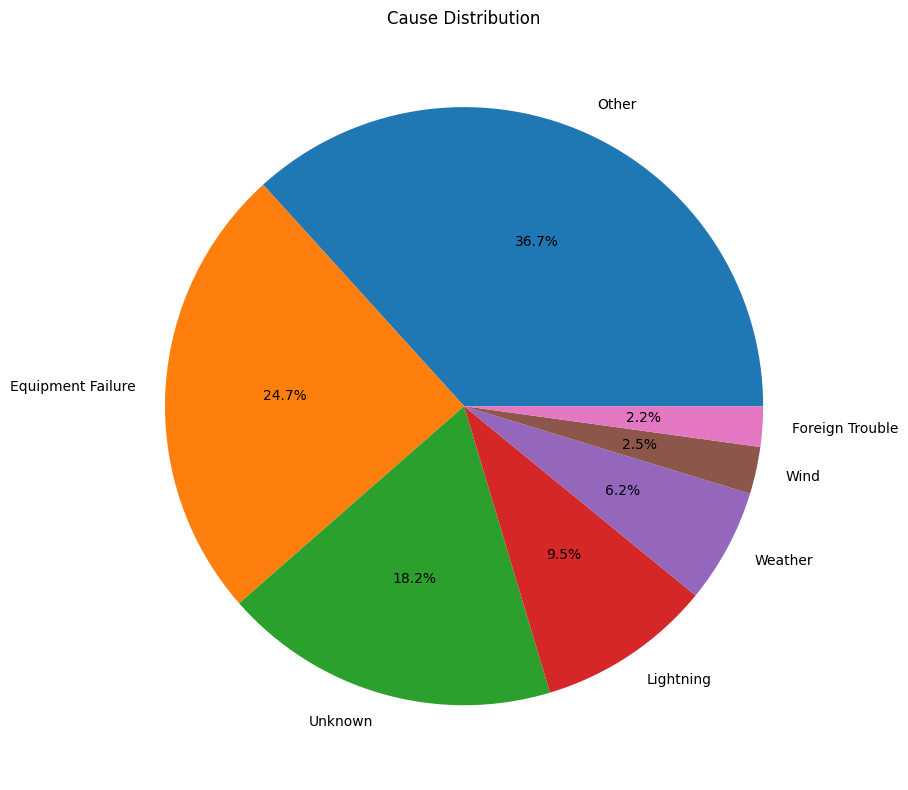

In [4]:
# Cause 分布統計
import matplotlib.pyplot as plt

cause_counts = df["Cause"].value_counts()

plt.figure(figsize=(10,8))
plt.pie(cause_counts, labels=cause_counts.index, autopct="%1.1f%%", startangle=0)
plt.title("Cause Distribution")
plt.tight_layout()
plt.show()

## 2.4 Duration 直方圖

1. 線性直方圖

2. Log 尺度下直方圖

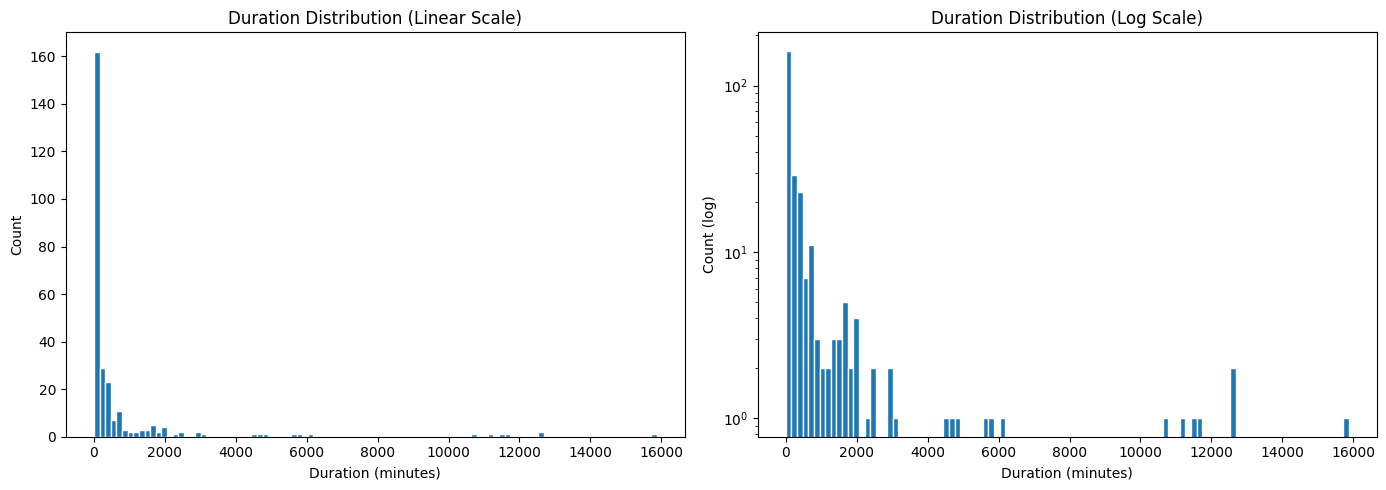

In [5]:
# Duration 直方圖
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 線性尺度
axes[0].hist(df["Duration (minutes)"], bins=100, edgecolor="white")
axes[0].set_title("Duration Distribution (Linear Scale)")
axes[0].set_xlabel("Duration (minutes)")
axes[0].set_ylabel("Count")

# Log 尺度
axes[1].hist(df["Duration (minutes)"], bins=100, edgecolor="white")
axes[1].set_yscale("log")
axes[1].set_title("Duration Distribution (Log Scale)")
axes[1].set_xlabel("Duration (minutes)")
axes[1].set_ylabel("Count (log)")

plt.tight_layout()
plt.show()

# 3. CCDF 計算與繪製

* 目的 : 計算並繪製修復時間的經驗互補累積分布函數（CCDF），以 log-log 尺度呈現。若分布具有重尾特性，資料點在 log-log 圖上會呈現近似線性的行為。此圖將作為後續 log-normal 擬合比較的基準。

* 橫軸 : 修復時間（分鐘），以 log 尺度呈現，範圍從 1 分鐘到數萬分鐘，跨越多個數量級。

* 縱軸 : P(X > x) 互補累積機率，即修復時間超過 x 分鐘的機率，以 log 尺度呈現。數值越小代表該修復時間越罕見。

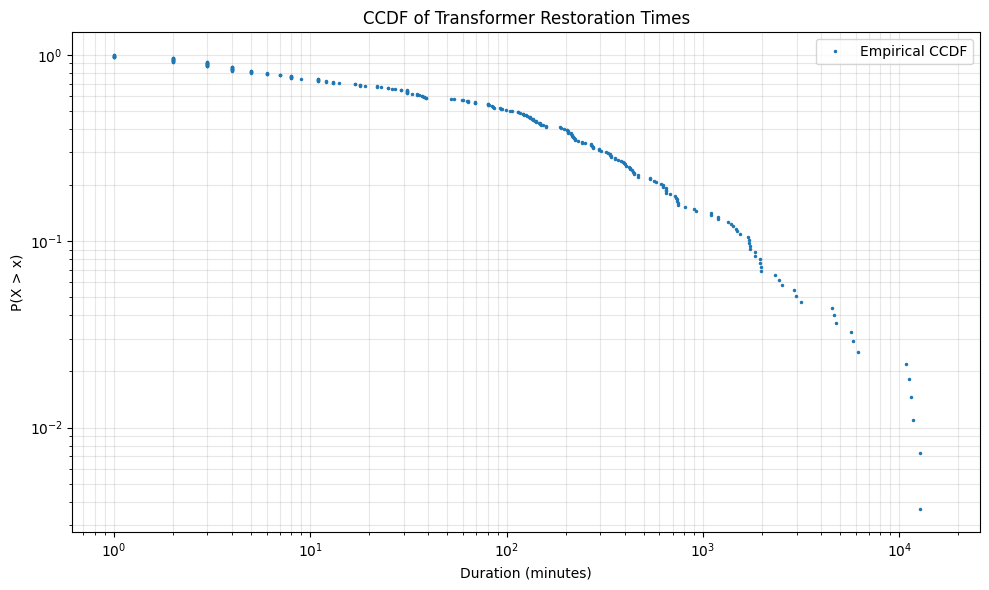

In [6]:
import numpy as np

# 依據修復時間做排序
duration_sorted = np.sort(df["Duration (minutes)"].values)

# 發生該修復時間的互補累積機率 (1-累積機率)
# 使用 arange 將 numpy 陣列做 [1,2...] 排列，也就是記數
ccdf = 1 - np.arange(1, len(duration_sorted) + 1) / len(duration_sorted)

plt.figure(figsize=(10, 6))
plt.loglog(duration_sorted, ccdf, marker=".", linestyle="none", markersize=3, label="Empirical CCDF")
plt.xlabel("Duration (minutes)")
plt.ylabel("P(X > x)")
plt.title("CCDF of Transformer Restoration Times")
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()

# 4. 函式分布擬合

* 對修復時間資料進行多種機率分布擬合，透過最大概似估計法（Maximum Likelihood Estimation, MLE）估計各分布的參數，並以 AIC（Akaike Information Criterion）作為模型選擇依據。
  
  1. **MLE（最大概似估計法）**：透過最大化對數概似函數來估計分布參數，即尋找一組參數使得觀測資料出現的機率最大。
   
        $$\hat{\theta} = \arg\max_{\theta} \sum_{i=1}^{n} \ln f(x_i \mid \theta)$$
   
       * 簡單來說就是找參數去擬合出近似實際資料的線型
    
  2. **AIC（赤池資訊準則）**：在對數概似值的基礎上對參數數量 $k$ 進行懲罰，避免過度擬合，數值越小代表模型越佳。

        $$AIC = 2k - 2\ln(\hat{L})$$
   
       * AIC 的絕對數值本身沒有意義，它只有在跟其他模型比較時才有意義，通常以 ΔAIC（與最佳模型的差距）作為判斷依據。

            | ΔAIC | 解讀 |
            |------|------|
            | 0 ~ 2 | 與最佳模型幾乎無差異，都值得考慮 |
            | 2 ~ 6 | 有一定差距，次佳模型支持度較弱 |
            | 6 ~ 10 | 差距明顯，次佳模型支持度很弱 |
            | > 10 | 幾乎可以排除該模型 |

  3. **KS D 統計量**：衡量實際 CCDF 與理論 CCDF 之間的最大絕對誤差值，越小代表曲線與實際資料可能越接近，作為輔助視覺判斷的參考指標
   
        $$D=xmax​∣Fempirical​(x)−Ftheoretical​(x)∣$$

* 候選分布涵蓋 Log-normal、Weibull、Gamma、Burr (XII)、Gen. Pareto、Gen. Gamma 共六種，涵蓋右偏、重尾、廣義形式等不同特性，以確保比較的完整性。

  


## 4.1 函式擬合

In [7]:
from scipy import stats

# 候選分布
candidates = {
    "Log-normal":  stats.lognorm,
    "Weibull":     stats.weibull_min,
    "Gamma":       stats.gamma,
    "Burr (XII)":  stats.burr,
    "Gen. Pareto": stats.genpareto,
    "Gen. Gamma":  stats.gengamma,
}

fit_results   = []
fitted_params = {}

for name, dist in candidates.items():
    try:
        params  = dist.fit(duration_sorted, floc=0)
        log_lik = dist.logpdf(duration_sorted, *params).sum()

        if not np.isfinite(log_lik):
            print(f"{name}: non-finite log-likelihood, skipped")
            continue

        k   = len(params) - 1
        aic = 2 * k - 2 * log_lik
        ks_stat, _ = stats.kstest(duration_sorted, dist.cdf, args=params)

        fit_results.append({
            "Distribution": name,
            "AIC"         : round(aic, 0),
            "KS D"        : round(ks_stat, 5),
            "params"      : params,
        })

        fitted_params[name] = (dist, params)

    except Exception as e:
        print(f"{name} fit failed: {e}")

results_df = pd.DataFrame(fit_results).sort_values("AIC").reset_index(drop=True)
results_df["ΔAIC"] = (results_df["AIC"] - results_df["AIC"].min()).round(0)

results_df[["Distribution", "AIC", "ΔAIC", "KS D"]]

,Distribution,AIC,ΔAIC,KS D
0,Log-normal,3645.0,0.0,0.07724
1,Gen. Gamma,3651.0,6.0,0.07818
2,Burr (XII),3665.0,20.0,0.08107
3,Weibull,3672.0,27.0,0.08249
4,Gen. Pareto,3682.0,37.0,0.11781
5,Gamma,3727.0,82.0,0.13236


## 4.2 視覺化

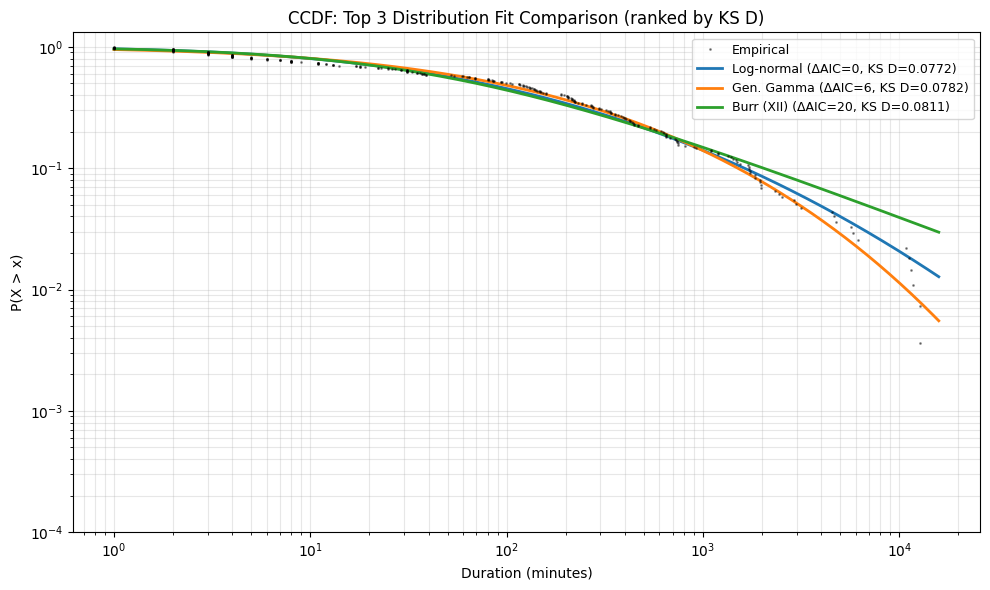

In [8]:
# 視覺化 CCDF 比較（Top 3 by KS D）
top3   = results_df.sort_values("KS D").head(3)["Distribution"].tolist()
x_plot = np.logspace(np.log10(duration_sorted.min()), np.log10(duration_sorted.max()), 600)
colors = ["tab:blue", "tab:orange", "tab:green"]

fig, ax = plt.subplots(figsize=(10, 6))
ax.loglog(duration_sorted, ccdf, "k.", markersize=2, alpha=0.4, label="Empirical", zorder=5)

for name, color in zip(top3, colors):
    dist, params = fitted_params[name]
    ccdf_th = 1 - dist.cdf(x_plot, *params)
    row = results_df[results_df["Distribution"] == name].iloc[0]
    ax.loglog(x_plot, ccdf_th, linewidth=2, color=color,
              label=f'{name} (ΔAIC={row["ΔAIC"]:.0f}, KS D={row["KS D"]:.4f})')

ax.set_xlabel("Duration (minutes)")
ax.set_ylabel("P(X > x)")
ax.set_title("CCDF: Top 3 Distribution Fit Comparison (ranked by KS D)")
ax.set_ylim(bottom=1e-4)
ax.legend(fontsize=9)
ax.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()

## 4.3 擬合結果說明

AIC 及 KS D 排名第一皆為 **Log-normal**，且視覺擬合結果亦最為理想，選擇理由如下：

**1. AIC 最低（ΔAIC = 0）**

僅含 μ、σ 兩個參數，表示過擬合情況較低，亦與電力系統恢復時間文獻中最常採用的分布一致。

**2. 尾段視覺擬合最佳**

* 在 < 1000 分鐘的 case 中 3 者在視覺化擬合表現類似，主要觀察尾部情況

- Gen. Gamma 視覺上 Log-normal 的表現類似，但尾段衰減過快，可能低估極端事件的發生機率，偏向非保守側
- Burr XII 尾段高估程度偏大，雖保守但與實際資料偏離較多
- Log-normal 在尾段（> 1000 分鐘）整體落於資料點上方，與實際資料最為貼近

**3. 偏保守側設計**

Log-normal 在尾段傾向略微高估超越機率，即對於相同發生機率，模型預測的恢復時間略長於實際觀測值，後續會針對整體估計是否為保守設計做期望值計算

# 5. 相對誤差檢核

* 原理

    > 對每個資料點 x，計算實際 CCDF 與 log-normal 理論 CCDF 之間的相對誤差：
    >
    > Relative Error = |F_empirical(x) - F_theoretical(x)| / F_empirical(x) => |預測值 - 實際值| / 實際值

* 相較於 KS test 只取最大差距，相對誤差法考慮每個點的誤差大小，能更全面反映整體的擬合品質，且不受樣本數影響。

* 誤差判斷標準：
    >
    > 誤差 < 5%：擬合非常好
    >
    > 誤差 5% ~ 10%：擬合良好，可接受
    >
    > 誤差 10% ~ 20%：擬合尚可，需注意偏離區間
    >
    > 誤差 > 20%：擬合較差，分布假設可能不適用

* 本資料的結果：

  * 一般統計：
    1. 中位數相對誤差 6.95%：整體擬合良好
    2. 平均相對誤差 8.65%：平均 > 中位數，呈現重尾現象
    3. 最大相對誤差 345.12%：尾部極端點偏離較大，反映重尾資料的現象

  * 離散化統計：
    1. 83.2% 的點位誤差 < 10%（非常好 + 良好合計），代表超過 4/5 的資料使用 Log-normal 分布進行估計都能有效描述
    2. 96.7% 的點位誤差 < 20%，也就是幾乎所有資料都在「尚可」以上
    3. 誤差 > 20% 的「偏差」點位僅佔 3.3%，集中在尾部極端區段

## 5.1 一般統計

In [9]:
# Log-normal 全域擬合參數
params_global = stats.lognorm.fit(duration_sorted, floc=0)
sigma = params_global[0]
mu    = np.log(params_global[2])

# 計算實際 CCDF 與理論 CCDF
ccdf_empirical = 1 - np.arange(1, len(duration_sorted) + 1) / len(duration_sorted)
ccdf_lognorm   = 1 - stats.lognorm.cdf(duration_sorted, s=sigma, scale=np.exp(mu))

# 過濾掉 ccdf_empirical = 0 的點，避免分母為零
mask = ccdf_empirical > 0
ccdf_empirical_valid = ccdf_empirical[mask]
ccdf_lognorm_valid   = ccdf_lognorm[mask]

# 相對誤差
rel_err = np.abs(ccdf_empirical_valid - ccdf_lognorm_valid) / ccdf_empirical_valid

# 一般統計
print("── 相對誤差分布 ──")
print(f"中位數相對誤差: {np.median(rel_err)*100:.2f}%")
print(f"平均相對誤差:   {np.mean(rel_err)*100:.2f}%")
print(f"最大相對誤差:   {rel_err.max()*100:.2f}%")

── 相對誤差分布 ──
中位數相對誤差: 6.95%
平均相對誤差:   8.65%
最大相對誤差:   345.12%


## 5.2 離散化統計

In [10]:
# 離散化統計
bins   = [(0, 0.05), (0.05, 0.10), (0.10, 0.20), (0.20, np.inf)]
labels = ["< 5%（非常好）", "5 ~ 10%（良好）", "10 ~ 20%（尚可）", "> 20%（偏差）"]
n_total    = len(rel_err)
cumulative = 0.0

rows = []
for (lo, hi), label in zip(bins, labels):
    cnt  = int(((rel_err >= lo) & (rel_err < hi)).sum())
    pct  = cnt / n_total * 100
    cumulative += pct
    rows.append({
        "誤差區間"    : label,
        "點數"        : cnt,
        "比例 (%)"    : round(pct, 1),
        "累積比例 (%)": round(cumulative, 1),
    })

pd.DataFrame(rows).set_index("誤差區間")

,點數,比例 (%),累積比例 (%)
誤差區間,,,
< 5%（非常好）,99,36.1,36.1
5 ~ 10%（良好）,129,47.1,83.2
10 ~ 20%（尚可）,37,13.5,96.7
> 20%（偏差）,9,3.3,100.0


## 5.3 視覺化

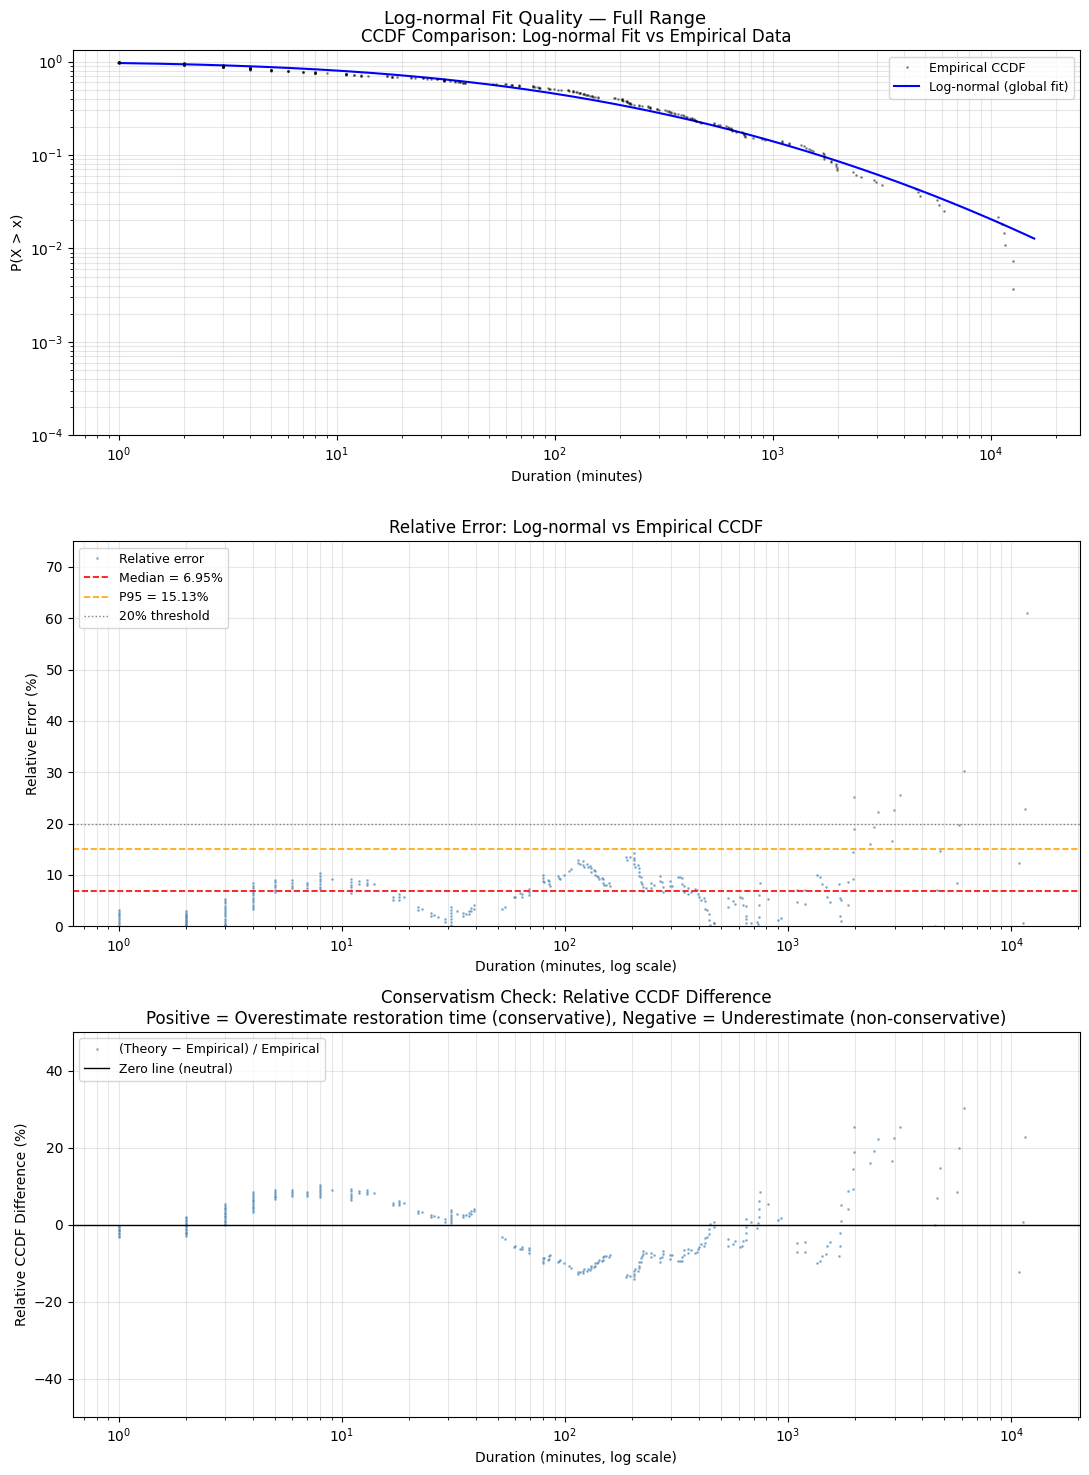

In [12]:
x_plot  = np.logspace(np.log10(duration_sorted.min()), np.log10(duration_sorted.max()), 600)
ccdf_th = 1 - stats.lognorm.cdf(x_plot, *params_global)

fig, axes = plt.subplots(3, 1, figsize=(11, 15))
fig.suptitle("Log-normal Fit Quality — Full Range", fontsize=13)

# Plot 1: CCDF comparison
ax = axes[0]
ax.loglog(duration_sorted, ccdf_empirical, "k.", markersize=2,
          alpha=0.35, label="Empirical CCDF", zorder=5)
ax.loglog(x_plot, ccdf_th, "b-", linewidth=1.5, label="Log-normal (global fit)")
ax.set_xlabel("Duration (minutes)")
ax.set_ylabel("P(X > x)")
ax.set_title("CCDF Comparison: Log-normal Fit vs Empirical Data")
ax.set_ylim(bottom=1e-4)
ax.legend(fontsize=9)
ax.grid(True, which="both", alpha=0.3)

# Plot 2: 相對誤差 vs duration
x_valid = duration_sorted[mask]

ax = axes[1]
ax.semilogx(x_valid, rel_err * 100,
            ".", color="steelblue", markersize=2, alpha=0.5, label="Relative error")
ax.axhline(np.median(rel_err) * 100, color="red", linestyle="--",
           linewidth=1.2, label=f"Median = {np.median(rel_err)*100:.2f}%")
ax.axhline(np.percentile(rel_err, 95) * 100, color="orange", linestyle="--",
           linewidth=1.2, label=f"P95 = {np.percentile(rel_err, 95)*100:.2f}%")
ax.axhline(20, color="gray", linestyle=":", linewidth=1.0, label="20% threshold")
ax.set_ylim(0, 75)
ax.set_xlabel("Duration (minutes, log scale)")
ax.set_ylabel("Relative Error (%)")
ax.set_title("Relative Error: Log-normal vs Empirical CCDF")
ax.legend(fontsize=9)
ax.grid(True, which="both", alpha=0.3)

# Plot 3: 理論 − 實際 CCDF 相對差值（保守性佐證）
ax = axes[2]

ccdf_th_data = 1 - stats.lognorm.cdf(duration_sorted, *params_global)
valid_p3     = ccdf_empirical > 0
rel_diff     = (ccdf_th_data[valid_p3] - ccdf_empirical[valid_p3]) / ccdf_empirical[valid_p3]

ax.semilogx(duration_sorted[valid_p3], rel_diff * 100, ".", color="steelblue",
            markersize=2, alpha=0.5, label="(Theory − Empirical) / Empirical")
ax.axhline(0, color="black", linewidth=1.0, linestyle="-", label="Zero line (neutral)")
ax.set_xlabel("Duration (minutes, log scale)")
ax.set_ylabel("Relative CCDF Difference (%)")
ax.set_title("Conservatism Check: Relative CCDF Difference\n"
             "Positive = Overestimate restoration time (conservative), Negative = Underestimate (non-conservative)")
ax.set_ylim(-50, 50)
ax.legend(fontsize=9)
ax.grid(True, which="both", alpha=0.3)

plt.tight_layout()
plt.show()

# 6. 使用全域擬合說明

* **不設擬合區間的理由**

    資料已於前處理階段以 **DOE-417 WECC 全域最大值（global_max）** 作為異常值截斷閾值，超過者直接移除。此步驟已剔除推測因替代供電而長期掛帳、不具搶修意義的紀錄。

    若在已清理的資料上再行設定擬合截斷點，等同對同一批資料進行**二次人為限制**，實際效果如下：

    截去表現不好的尾部以 worst case 填補，擬合曲線在截斷點前視覺上看似變好，但實際上是截斷後直接跳至最差情況，整體誤差反而增大

* **結論**

    由於異常值已於前處理中移除，Log-normal 全域擬合結果可直接作為**恢復時間－機率模擬**的基礎，無需額外設定擬合區間。後續將驗證此做法在整體期望值層面的保守性。

# 7. 保守設計驗證

* **驗證邏輯**

    由於變電所停電為隨機事件，單一事件的估計值可能高估或低估，但可靠度評估真正關心的是**長期多次事件下的期望恢復時間**。因此以下結果成立，則表示對數常態分佈估計值偏保守側：

    > 若 ΔE[T] > 0，代表模型在各機率點的恢復時間估計期望值偏向高估，模擬結果具保守性。

* **定義**

    | 指標 | 計算方式 | 說明 |
    |------|----------|------|
    | 逐點誤差 ΔTᵢ | x_estimated(pᵢ) − x_empirical(pᵢ) | 正值代表高估，負值代表低估 |
    | 誤差期望值 ΔE[T] | (1/n) Σ ΔTᵢ | 各事件誤差的算術平均，反映模擬的整體偏向 |
    | 相對高估比例 | ΔE[T] / mean(x) × 100% | 相對於歷史平均恢復時間的高估幅度 |

* **本資料的結果**

    * 誤差期望值 ΔE[T]：+225.40 min（+3.76 hr）
    * 相對高估比例：+30.32%
    * 方向：**高估（保守）**

* Log-normal 全域擬合在整體期望值層面偏向保守側，平均高估恢復時間約 30%

In [13]:
# 每個實際資料點對應的超越機率
p_i = ccdf_empirical[mask]

# 實際修復時間的算術平均
actual_mean = duration_sorted.mean()

# 在相同超越機率下，Log-normal 反查估計恢復時間
x_empirical = duration_sorted[mask]
x_estimated = stats.lognorm.ppf(1 - p_i, s=sigma, scale=np.exp(mu))

# 逐點差值（估計 - 實際）
delta_T = x_estimated - x_empirical

# 等權重期望誤差
delta_E_T = delta_T.mean()
pct_delta = delta_E_T / actual_mean * 100

print(f"誤差期望值 ΔE[T] : {delta_E_T:+.2f} min  ({delta_E_T/60:+.4f} hr)")
print(f"相對高估比例     : {pct_delta:+.2f}%")
print(f"方向             : {'高估（保守）' if delta_E_T > 0 else '低估（非保守）'}")

誤差期望值 ΔE[T] : +225.40 min  (+3.7567 hr)
相對高估比例     : +30.32%
方向             : 高估（保守）


# 8. 小說明

關於重尾處是否做額外線性回歸擬合，個人判斷不需要，主要原因為，這可以看做成 over/under fitting 的選擇問題，當今天選擇使用線性回歸擬合，其實等於是看著答案在做答，這樣的風險在於在不同環境情況下，你的資料點有可能會超出擬合線而偏不保守，回過頭來看，若維持原樣，在變電所資料中頂多是在 1% 附近的預測不準而已，而在線路資料中則是在 0.1% 處預測不準確，且 2 者皆偏保守估計，符合偏保守側的模擬原則

* 變電所擬合成果
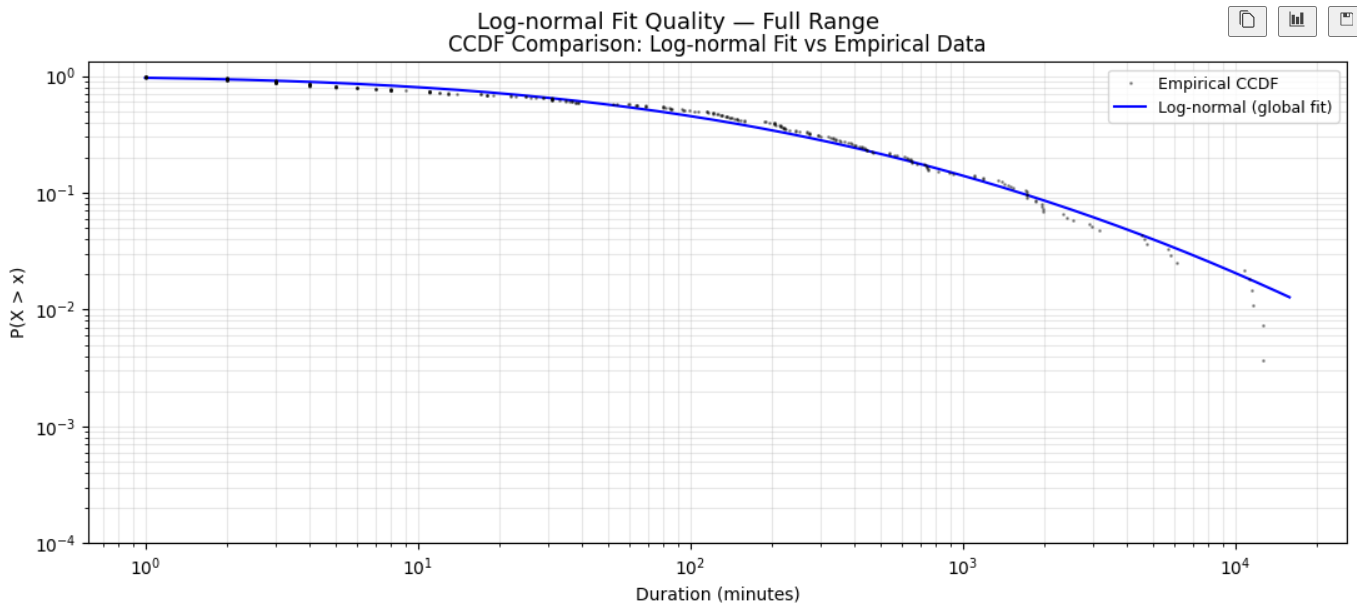

* 線路擬合成果
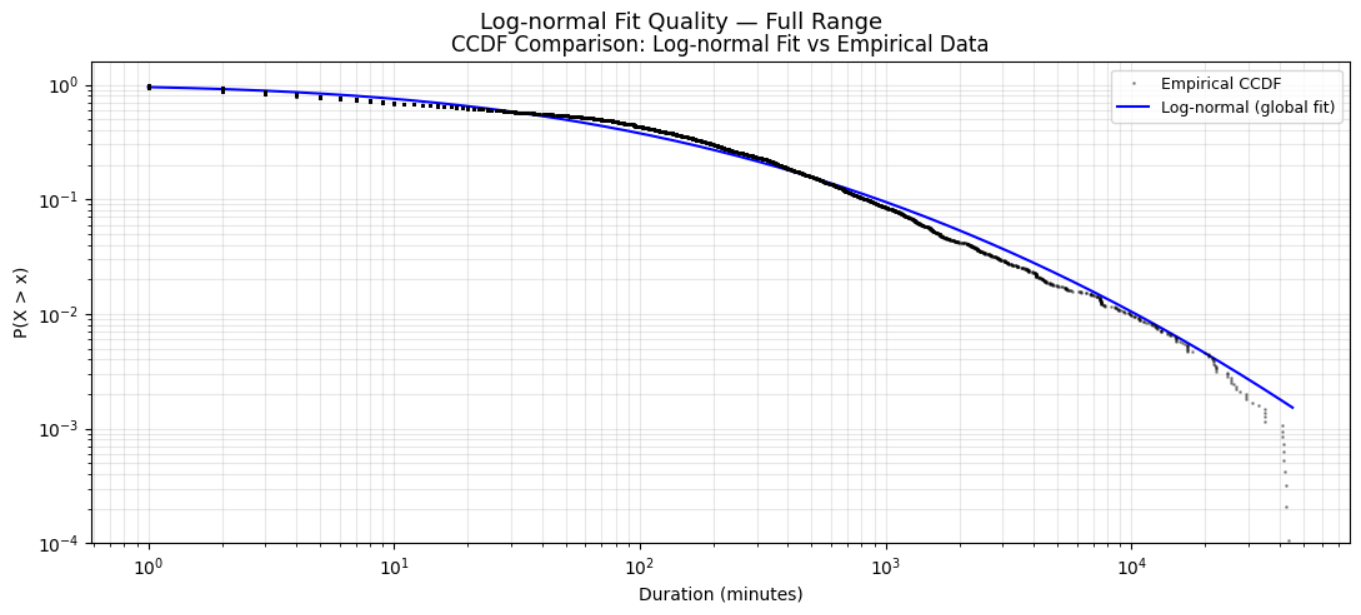